In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(path):
    for file in files:
        if "HI" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Resume WINNER CHIOMA UNUAGBON 2.pdf
/content/drive/MyDrive/Resume WINNER CHIOMA UNUAGBON 4.pdf
/content/drive/MyDrive/Birth Certificate - WINNER CHIOMA UNUAGBON.pdf
/content/drive/MyDrive/HI-Small_Trans.csv
/content/drive/MyDrive/HI SMALL PATTERNS.xlsx
/content/drive/MyDrive/HI-Small_Patterns.txt
/content/drive/MyDrive/Colab Notebooks/EDA NOTEBOOK_WINNER CHIOMA UNUAGBON.ipynb


In [4]:
import pandas as pd
transactions = pd.read_csv("/content/drive/MyDrive/HI-Small_Trans.csv")

In [5]:
transactions.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [7]:
transactions.isnull().sum()

,0
Timestamp,0
From Bank,0
Account,0
To Bank,0
Account.1,0
Amount Received,0
Receiving Currency,0
Amount Paid,0
Payment Currency,0
Payment Format,0


In [8]:
patterns = pd.read_excel(
    "/content/drive/MyDrive/HI SMALL PATTERNS.xlsx",
    engine="openpyxl"
)

In [9]:
patterns.head(5)

,BEGIN LAUNDERING ATTEMPT - FAN-OUT: Max 16-degree Fan-Out
0,"2022/09/01 00:06,021174,800737690,012,80011F99..."
1,"2022/09/01 04:33,021174,800737690,020,80020C5B..."
2,"2022/09/01 09:14,021174,800737690,020,80006A5E..."
3,"2022/09/01 09:56,021174,800737690,00220,8007A5..."
4,"2022/09/01 11:28,021174,800737690,001244,80093..."


In [10]:
transactions = transactions.rename(columns={
    'Timestamp': 'timestamp',
    'From Bank': 'sender_bank',
    'Account': 'sender_account',
    'To Bank': 'receiver_bank',
    'Account.1': 'receiver_account',
    'Amount Received': 'amount_received',
    'Receiving Currency': 'receiving_currency',
    'Amount Paid': 'amount_paid',
    'Payment Currency': 'payment_currency',
    'Payment Format': 'payment_format',
    'Is Laundering': 'is_laundering'
})

In [11]:
transactions["is_laundering"].value_counts()

,count
is_laundering,
0,5073168
1,5177


In [12]:
print(transactions.columns.tolist())

['timestamp', 'sender_bank', 'sender_account', 'receiver_bank', 'receiver_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering']


In [13]:
df = transactions.copy()

In [14]:
print(df.columns.tolist())

['timestamp', 'sender_bank', 'sender_account', 'receiver_bank', 'receiver_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering']


In [15]:
df["is_laundering"].value_counts(normalize=True)

,proportion
is_laundering,
0,0.998981
1,0.001019


In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [17]:
aml_df = df.groupby(
    ["sender_bank", "sender_account"]
).agg(
    transaction_count=("sender_account", "size"),
    total_sent=("amount_paid", "sum"),
    unique_receivers=("receiver_account", "nunique"),
    first_txn=("timestamp", "min"),
    last_txn=("timestamp", "max"),
    laundering_count=("is_laundering", "sum"),
    laundering_rate=("is_laundering", "mean")
).reset_index()

In [18]:
received = (
    df.groupby("receiver_account")["amount_received"]
      .sum()
      .reset_index(name="total_received")
)

aml_df = aml_df.merge(
    received,
    left_on="sender_account",
    right_on="receiver_account",
    how="left"
)

aml_df["total_received"] = aml_df["total_received"].fillna(0)

aml_df.drop(columns=["receiver_account"], inplace=True)

In [19]:
fan_out = (
    df.groupby("sender_account")["receiver_account"]
      .nunique()
      .reset_index(name="fan_out")
)

aml_df = aml_df.merge(
    fan_out,
    on="sender_account",
    how="left"
)

In [20]:
aml_df["fan_out_percentile"] = aml_df["fan_out"].rank(pct=True)

In [21]:
fan_in = (
    df.groupby("receiver_account")["sender_account"]
      .nunique()
      .reset_index(name="fan_in")
)

aml_df = aml_df.merge(
    fan_in,
    left_on="sender_account",
    right_on="receiver_account",
    how="left"
)

aml_df["fan_in"] = aml_df["fan_in"].fillna(0)

aml_df.drop(columns=["receiver_account"], inplace=True)

In [22]:
aml_df["fan_in_percentile"] = aml_df["fan_in"].rank(pct=True)

In [23]:
aml_df["active_days"] = (
    aml_df["last_txn"] -
    aml_df["first_txn"]
).dt.days + 1

In [24]:
aml_df["txn_percentile"] = aml_df["transaction_count"].rank(pct=True)

In [25]:
aml_df["sent_percentile"] = aml_df["total_sent"].rank(pct=True)

In [26]:
aml_df["risk_score"] = (
      35 * aml_df["txn_percentile"]
    + 25 * aml_df["fan_out_percentile"]
    + 15 * aml_df["fan_in_percentile"]
    + 15 * aml_df["sent_percentile"]
    + 10 * aml_df["laundering_rate"]
)

In [27]:
aml_df["risk_category"] = pd.qcut(
    aml_df["risk_score"],
    q=[0, 0.80, 0.95, 0.99, 1],
    labels=["Low", "Medium", "High", "Critical"]
)

In [28]:
def risk_driver(row):

    drivers = []

    if row["txn_percentile"] >= 0.95:
        drivers.append("High Transaction Activity")

    if row["fan_out_percentile"] >= 0.95:
        drivers.append("High Fan-Out Activity")

    if row["fan_in_percentile"] >= 0.95:
        drivers.append("High Fan-In Activity")

    if row["sent_percentile"] >= 0.95:
        drivers.append("High Value Movement")

    if row["laundering_count"] > 0:
        drivers.append("Known Laundering Activity")

    if len(drivers) == 0:
        return "Normal Activity"

    return ", ".join(drivers)

aml_df["risk_driver"] = aml_df.apply(risk_driver, axis=1)

In [29]:
aml_df["risk_driver"] = aml_df.apply(
    risk_driver,
    axis=1
)

In [30]:
print(aml_df.columns.to_list())

['sender_bank', 'sender_account', 'transaction_count', 'total_sent', 'unique_receivers', 'first_txn', 'last_txn', 'laundering_count', 'laundering_rate', 'total_received', 'fan_out', 'fan_out_percentile', 'fan_in', 'fan_in_percentile', 'active_days', 'txn_percentile', 'sent_percentile', 'risk_score', 'risk_category', 'risk_driver']


In [31]:
aml_table = aml_df[[





    "sender_bank",

    "sender_account",



    "transaction_count",

    "txn_percentile",

    "first_txn",

    "last_txn",

    "active_days",



    "total_sent",

    "total_received",



    "unique_receivers",

    "fan_out",

    "fan_out_percentile",

    "fan_in",

    "fan_in_percentile",



    "laundering_count",

    "laundering_rate",



    "risk_score",

    "risk_category",

    "risk_driver"

]].copy()

In [32]:
aml_df.head(10)

,sender_bank,sender_account,transaction_count,total_sent,unique_receivers,first_txn,last_txn,laundering_count,laundering_rate,total_received,fan_out,fan_out_percentile,fan_in,fan_in_percentile,active_days,txn_percentile,sent_percentile,risk_score,risk_category,risk_driver
0,1,800042CB0,134,1.275401e+06,13,2022-09-01 00:13:00,2022-09-10 15:20:00,0,0.000000,40018.84,13,0.996796,1.0,0.346126,10,0.997579,0.877853,78.194866,Medium,"High Transaction Activity, High Fan-Out Activity"
1,1,800054E60,222,2.781327e+07,13,2022-09-01 02:47:00,2022-09-10 18:55:00,0,0.000000,975938.43,13,0.996796,2.0,0.584992,10,0.999860,0.971398,83.260857,High,"High Transaction Activity, High Fan-Out Activi..."
2,1,8000555D0,128,1.596319e+08,9,2022-09-01 00:20:00,2022-09-10 22:14:00,0,0.000000,3158455.22,9,0.984577,2.0,0.584992,10,0.997034,0.989052,83.121299,High,"High Transaction Activity, High Fan-Out Activi..."
3,1,800056160,89,2.106860e+05,11,2022-09-01 00:02:00,2022-09-10 17:20:00,1,0.011236,6227.20,11,0.993173,7.0,0.987852,10,0.988884,0.761985,85.800198,Critical,"High Transaction Activity, High Fan-Out Activi..."
4,1,800056370,131,5.500107e+07,9,2022-09-01 00:04:00,2022-09-10 23:42:00,0,0.000000,81579.64,9,0.984577,2.0,0.584992,10,0.997288,0.979978,82.994055,High,"High Transaction Activity, High Fan-Out Activi..."
5,1,800056A50,107,1.833335e+07,13,2022-09-01 02:03:00,2022-09-10 17:57:00,0,0.000000,49590.67,13,0.996796,1.0,0.346126,10,0.994073,0.963946,79.363545,Medium,"High Transaction Activity, High Fan-Out Activi..."
6,1,800056CB0,114,1.404377e+06,12,2022-09-01 00:02:00,2022-09-10 07:56:00,0,0.000000,40942.76,12,0.995318,1.0,0.346126,10,0.995312,0.882549,78.148995,Medium,"High Transaction Activity, High Fan-Out Activity"
7,1,800057020,210,3.497914e+06,15,2022-09-01 01:46:00,2022-09-10 23:21:00,0,0.000000,142707.98,15,0.998359,1.0,0.346126,10,0.999826,0.920837,78.957337,Medium,"High Transaction Activity, High Fan-Out Activity"
8,1,800057620,45,2.006922e+06,3,2022-09-01 00:03:00,2022-09-09 22:16:00,0,0.000000,98948.11,3,0.848399,2.0,0.584992,9,0.947933,0.899028,76.647951,Medium,Normal Activity
9,1,800057A10,123,4.913023e+07,6,2022-09-01 00:00:00,2022-09-10 22:29:00,0,0.000000,49099916.06,6,0.956161,1.0,0.346126,10,0.996508,0.978658,78.653569,Medium,"High Transaction Activity, High Fan-Out Activi..."


In [33]:
aml_df.tail(5)

,sender_bank,sender_account,transaction_count,total_sent,unique_receivers,first_txn,last_txn,laundering_count,laundering_rate,total_received,fan_out,fan_out_percentile,fan_in,fan_in_percentile,active_days,txn_percentile,sent_percentile,risk_score,risk_category,risk_driver
496994,356295,81495EE41,2,0.008984,1,2022-09-02 08:39:00,2022-09-09 17:12:00,0,0.0,0.0,1,0.28894,0.0,0.095019,8,0.466561,0.002247,25.012153,Low,Normal Activity
496995,356296,81495F061,2,0.018728,1,2022-09-02 03:02:00,2022-09-09 20:04:00,0,0.0,0.0,1,0.28894,0.0,0.095019,8,0.466561,0.003060,25.024346,Low,Normal Activity
496996,356300,814960F41,3,0.584486,1,2022-09-01 10:39:00,2022-09-09 21:24:00,0,0.0,0.0,1,0.28894,0.0,0.095019,9,0.669720,0.011668,32.264004,Low,Normal Activity
496997,356302,814962711,2,0.009458,1,2022-09-02 14:16:00,2022-09-09 18:54:00,0,0.0,0.0,1,0.28894,0.0,0.095019,8,0.466561,0.002291,25.012802,Low,Normal Activity
496998,356303,814963711,2,0.020512,1,2022-09-02 09:23:00,2022-09-09 11:01:00,0,0.0,0.0,1,0.28894,0.0,0.095019,8,0.466561,0.003203,25.026489,Low,Normal Activity


In [34]:
aml_df["risk_score"].describe()

,risk_score
count,496999.000000
mean,45.017917
std,19.978070
min,14.027563
25%,27.160507
50%,40.109145
75%,62.832179
max,92.017449


In [35]:
aml_df["risk_category"].value_counts()

,count
risk_category,
Low,397599
Medium,74550
High,19880
Critical,4970


In [36]:
aml_df["transaction_count"].describe()

,transaction_count
count,496999.000000
mean,10.218019
std,290.282946
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,168672.000000


In [37]:
aml_df["txn_percentile"].describe()

,txn_percentile
count,496999.000000
mean,0.500001
std,0.279578
min,0.153677
25%,0.153677
50%,0.466561
75%,0.747544
max,1.000000


In [38]:
aml_df.shape

(496999, 20)

In [39]:
def risk_driver(row):

    if row["laundering_count"] > 0:
        return "Laundering"

    elif row["txn_percentile"] >= 0.95:
        return "High Activity"

    elif row["fan_out_percentile"] >= 0.95:
        return "Fan-Out"

    elif row["fan_in_percentile"] >= 0.95:
        return "Fan-In"

    elif row["sent_percentile"] >= 0.95:
        return "High Value"

    else:
        return "Normal"

aml_df["risk_driver"] = aml_df.apply(risk_driver, axis=1)

In [40]:
aml_df["risk_driver"].value_counts().head(10)

,count
risk_driver,
Normal,418484
High Activity,24143
Fan-In,23001
High Value,15444
Fan-Out,12551
Laundering,3376


In [41]:
aml_df["risk_category"].value_counts()

,count
risk_category,
Low,397599
Medium,74550
High,19880
Critical,4970


In [42]:
import numpy as np

aml_df["txn_log"] = np.log1p(aml_df["transaction_count"])
aml_df["sent_log"] = np.log1p(aml_df["total_sent"])

In [43]:
aml_df["txn_percentile"] = aml_df["txn_log"].rank(pct=True)
aml_df["sent_percentile"] = aml_df["sent_log"].rank(pct=True)

In [44]:
aml_df.head(10)

,sender_bank,sender_account,transaction_count,total_sent,unique_receivers,first_txn,last_txn,laundering_count,laundering_rate,total_received,...,fan_in,fan_in_percentile,active_days,txn_percentile,sent_percentile,risk_score,risk_category,risk_driver,txn_log,sent_log
0,1,800042CB0,134,1.275401e+06,13,2022-09-01 00:13:00,2022-09-10 15:20:00,0,0.000000,40018.84,...,1.0,0.346126,10,0.997579,0.877853,78.194866,Medium,High Activity,4.905275,14.058772
1,1,800054E60,222,2.781327e+07,13,2022-09-01 02:47:00,2022-09-10 18:55:00,0,0.000000,975938.43,...,2.0,0.584992,10,0.999860,0.971398,83.260857,High,High Activity,5.407172,17.141024
2,1,8000555D0,128,1.596319e+08,9,2022-09-01 00:20:00,2022-09-10 22:14:00,0,0.000000,3158455.22,...,2.0,0.584992,10,0.997034,0.989052,83.121299,High,High Activity,4.859812,18.888381
3,1,800056160,89,2.106860e+05,11,2022-09-01 00:02:00,2022-09-10 17:20:00,1,0.011236,6227.20,...,7.0,0.987852,10,0.988884,0.761985,85.800198,Critical,Laundering,4.499810,12.258129
4,1,800056370,131,5.500107e+07,9,2022-09-01 00:04:00,2022-09-10 23:42:00,0,0.000000,81579.64,...,2.0,0.584992,10,0.997288,0.979978,82.994055,High,High Activity,4.882802,17.822863
5,1,800056A50,107,1.833335e+07,13,2022-09-01 02:03:00,2022-09-10 17:57:00,0,0.000000,49590.67,...,1.0,0.346126,10,0.994073,0.963946,79.363545,Medium,High Activity,4.682131,16.724233
6,1,800056CB0,114,1.404377e+06,12,2022-09-01 00:02:00,2022-09-10 07:56:00,0,0.000000,40942.76,...,1.0,0.346126,10,0.995312,0.882549,78.148995,Medium,High Activity,4.744932,14.155105
7,1,800057020,210,3.497914e+06,15,2022-09-01 01:46:00,2022-09-10 23:21:00,0,0.000000,142707.98,...,1.0,0.346126,10,0.999826,0.920837,78.957337,Medium,High Activity,5.351858,15.067678
8,1,800057620,45,2.006922e+06,3,2022-09-01 00:03:00,2022-09-09 22:16:00,0,0.000000,98948.11,...,2.0,0.584992,9,0.947933,0.899028,76.647951,Medium,Normal,3.828641,14.512113
9,1,800057A10,123,4.913023e+07,6,2022-09-01 00:00:00,2022-09-10 22:29:00,0,0.000000,49099916.06,...,1.0,0.346126,10,0.996508,0.978658,78.653569,Medium,High Activity,4.820282,17.709985


In [45]:
aml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496999 entries, 0 to 496998
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   sender_bank         496999 non-null  int64         
 1   sender_account      496999 non-null  object        
 2   transaction_count   496999 non-null  int64         
 3   total_sent          496999 non-null  float64       
 4   unique_receivers    496999 non-null  int64         
 5   first_txn           496999 non-null  datetime64[ns]
 6   last_txn            496999 non-null  datetime64[ns]
 7   laundering_count    496999 non-null  int64         
 8   laundering_rate     496999 non-null  float64       
 9   total_received      496999 non-null  float64       
 10  fan_out             496999 non-null  int64         
 11  fan_out_percentile  496999 non-null  float64       
 12  fan_in              496999 non-null  float64       
 13  fan_in_percentile   496999 no

In [46]:
aml_df.describe()

,sender_bank,transaction_count,total_sent,unique_receivers,first_txn,last_txn,laundering_count,laundering_rate,total_received,fan_out,fan_out_percentile,fan_in,fan_in_percentile,active_days,txn_percentile,sent_percentile,risk_score,txn_log,sent_log
count,496999.000000,496999.000000,4.969990e+05,496999.000000,496999,496999,496999.000000,496999.000000,4.969990e+05,496999.000000,496999.000000,496999.000000,496999.000000,496999.000000,496999.000000,496999.000000,496999.000000,496999.000000,4.969990e+05
mean,104274.275612,10.218019,4.607584e+07,2.043739,2022-09-01 11:07:43.175217664,2022-09-05 11:59:57.680398080,0.010417,0.001783,5.944585e+07,2.043795,0.500001,1.962670,0.500001,4.705786,0.500001,0.500001,45.017917,1.551453,9.568066e+00
min,1.000000,1.000000,1.000000e-06,1.000000,2022-09-01 00:00:00,2022-09-01 00:00:00,0.000000,0.000000,0.000000e+00,1.000000,0.288940,0.000000,0.095019,1.000000,0.153677,0.000004,14.027563,0.693147,9.999995e-07
25%,11107.000000,1.000000,1.088165e+03,1.000000,2022-09-01 00:13:00,2022-09-01 08:08:00,0.000000,0.000000,1.075950e+02,1.000000,0.288940,1.000000,0.346126,1.000000,0.153677,0.250002,27.160507,0.693147,6.993167e+00
50%,32049.000000,2.000000,1.239173e+04,1.000000,2022-09-01 00:49:00,2022-09-04 16:53:00,0.000000,0.000000,1.367382e+04,1.000000,0.288940,1.000000,0.346126,3.000000,0.466561,0.500000,40.109145,1.098612,9.424865e+00
75%,218202.000000,5.000000,1.806235e+05,2.000000,2022-09-01 15:24:00,2022-09-09 16:34:00,0.000000,0.000000,2.372999e+05,2.000000,0.690814,3.000000,0.766463,9.000000,0.747544,0.750001,62.832179,1.791759,1.210418e+01
max,356303.000000,168672.000000,1.505696e+12,14230.000000,2022-09-14 14:10:00,2022-09-18 16:18:00,243.000000,1.000000,1.486636e+12,14230.000000,1.000000,545.000000,1.000000,18.000000,1.000000,1.000000,92.017449,12.035717,2.804028e+01
std,122622.877754,290.282946,3.995375e+09,24.630535,NaN,NaN,0.465233,0.028399,5.013511e+09,24.630541,0.257346,2.624396,0.281351,3.805708,0.279578,0.288675,19.978070,1.061786,3.851006e+00


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

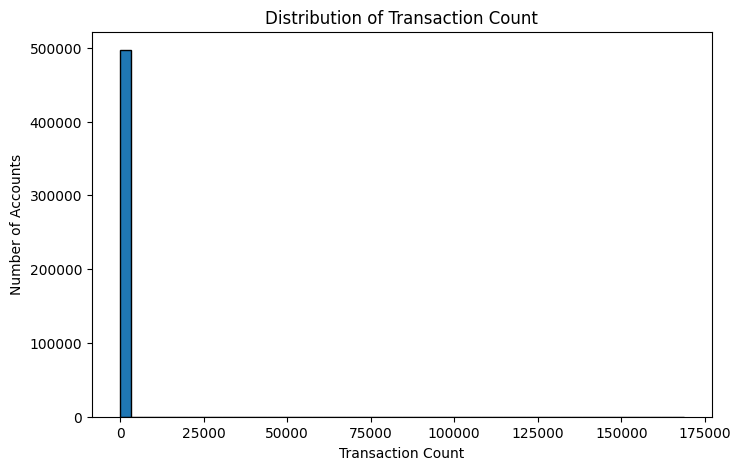

In [48]:
plt.figure(figsize=(8,5))

plt.hist(
    aml_df['transaction_count'],
    bins=50,
    edgecolor='black'
)

plt.title('Distribution of Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel('Number of Accounts')

plt.show()

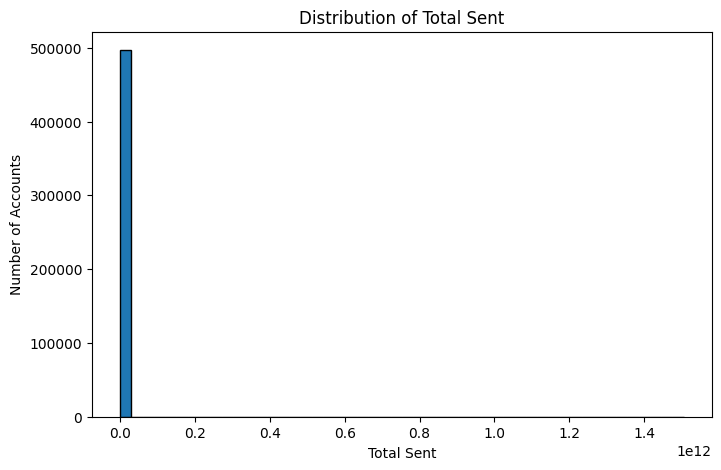

In [49]:
plt.figure(figsize=(8,5))

plt.hist(
    aml_df['total_sent'],
    bins=50,
    edgecolor='black'
)

plt.title('Distribution of Total Sent')
plt.xlabel('Total Sent')
plt.ylabel('Number of Accounts')

plt.show()

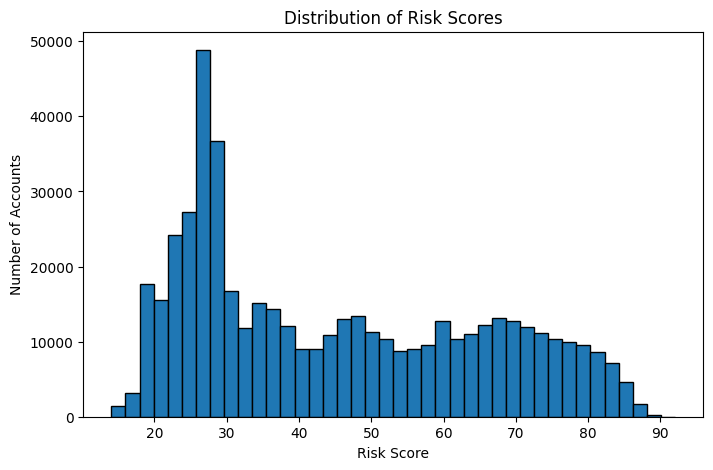

In [50]:
plt.figure(figsize=(8,5))

plt.hist(
    aml_df['risk_score'],
    bins=40,
    edgecolor='black'
)

plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Number of Accounts')

plt.show()

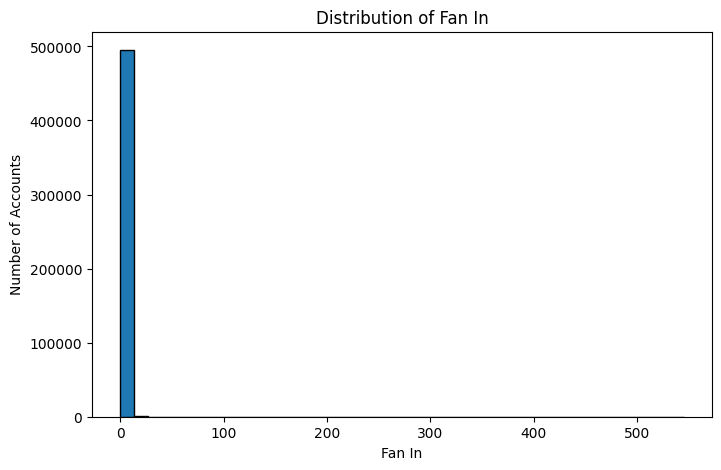

In [51]:
plt.figure(figsize=(8,5))

plt.hist(
    aml_df['fan_in'],
    bins=40,
    edgecolor='black'
)

plt.title('Distribution of Fan In')
plt.xlabel('Fan In')
plt.ylabel('Number of Accounts')

plt.show()

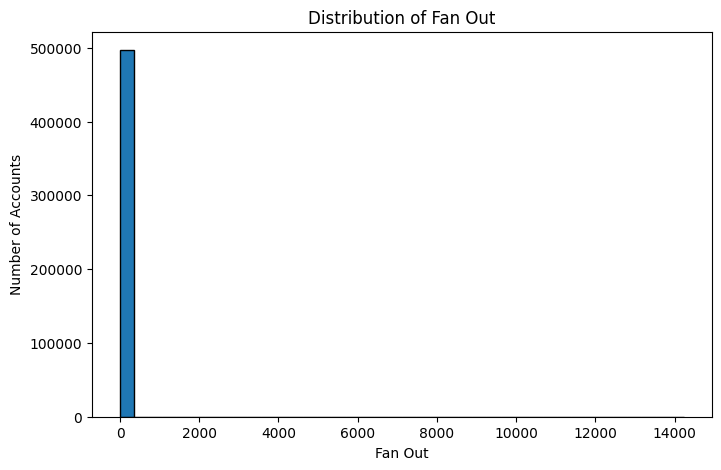

In [52]:
plt.figure(figsize=(8,5))

plt.hist(
    aml_df['fan_out'],
    bins=40,
    edgecolor='black'
)

plt.title('Distribution of Fan Out')
plt.xlabel('Fan Out')
plt.ylabel('Number of Accounts')

plt.show()

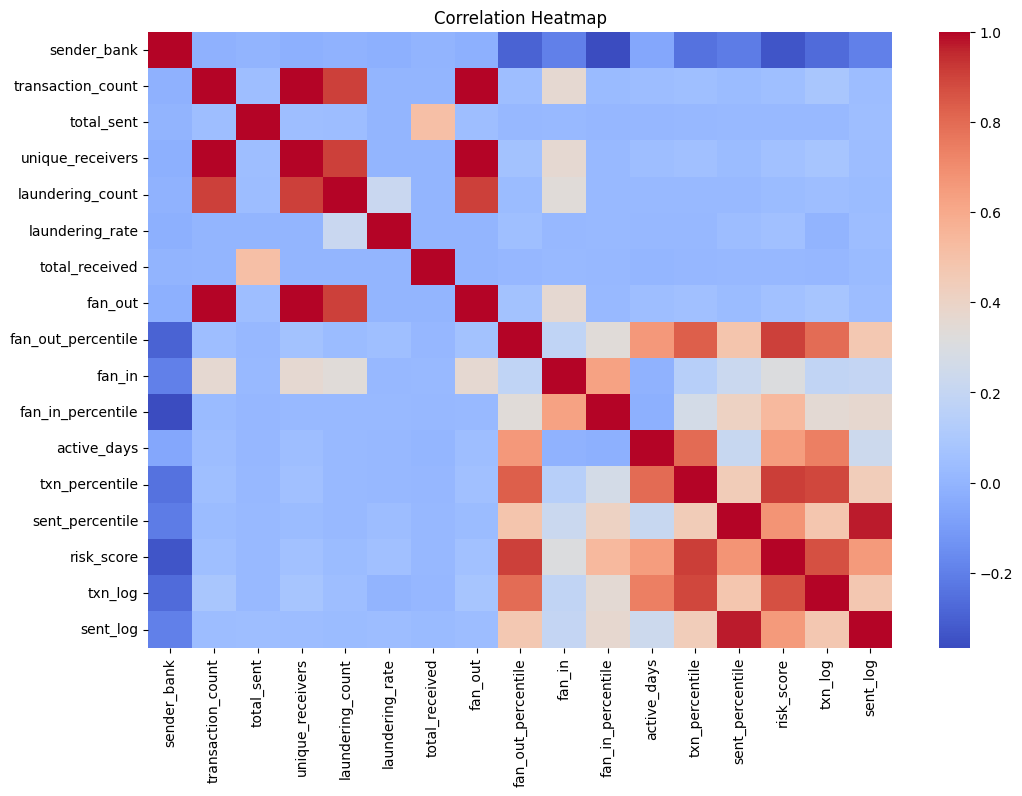

In [53]:
plt.figure(figsize=(12,8))

numeric_data = aml_df.select_dtypes(include='number')

sns.heatmap(
    numeric_data.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

In [54]:
aml_df.to_csv("aml_table_final.csv", index=False)


In [55]:
aml_df.to_parquet("aml_table_final.parquet", index=False)

In [56]:
from google.colab import files
files.download("aml_table_final.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
import pandas as pd


df = pd.read_csv("aml_table_final.csv")


df_sample = df.sample(n=1000, random_state=42)


df_sample.to_csv("sample_transactions.csv", index=False)

In [58]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/HI-Small_Trans.csv")

In [59]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=1_000_000,
    stratify=df["Is Laundering"],
    random_state=42
)

print("Sample Shape:", df_sample.shape)
print(df_sample["Is Laundering"].value_counts())

Sample Shape: (1000000, 11)
Is Laundering
0    998981
1      1019
Name: count, dtype: int64


In [60]:
features = [
    "From Bank",
    "To Bank",
    "Amount Paid",
    "Payment Format"
]

X = df_sample[features]
y = df_sample["Is Laundering"]

In [61]:
print(X.head())
print(y.head())

         From Bank  To Bank  Amount Paid Payment Format
2599463         15    29467    178610.81           Wire
1943268         14    29715       505.39         Cheque
1666787     120292    20486      1415.07           Cash
4150290         70   111443   1307389.06           Cash
267127      228101       15        15.70    Credit Card
2599463    0
1943268    0
1666787    0
4150290    0
267127     0
Name: Is Laundering, dtype: int64


In [62]:
df_sample["Timestamp"] = pd.to_datetime(df_sample["Timestamp"])

df_sample["hour"] = df_sample["Timestamp"].dt.hour
df_sample["weekday"] = df_sample["Timestamp"].dt.dayofweek

In [63]:
features = [
    "From Bank",
    "To Bank",
    "Amount Paid",
    "hour",
    "weekday",
    "Payment Format"
]

X = df_sample[features]
y = df_sample["Is Laundering"]

In [64]:
X = pd.get_dummies(
    X,
    columns=["Payment Format"],
    drop_first=False
)

print(X.head())

         From Bank  To Bank  Amount Paid  hour  weekday  Payment Format_ACH  \
2599463         15    29467    178610.81    15        0               False   
1943268         14    29715       505.39     7        5               False   
1666787     120292    20486      1415.07    17        4               False   
4150290         70   111443   1307389.06    20        3               False   
267127      228101       15        15.70     0        3               False   

         Payment Format_Bitcoin  Payment Format_Cash  Payment Format_Cheque  \
2599463                   False                False                  False   
1943268                   False                False                   True   
1666787                   False                 True                  False   
4150290                   False                 True                  False   
267127                    False                False                  False   

         Payment Format_Credit Card  Payment Forma

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800000, 12)
Testing set: (200000, 12)


In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [67]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199796
           1       0.00      0.00      0.00       204

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       1.00      1.00      1.00    200000


Confusion Matrix:
[[199796      0]
 [   204      0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
print(y_train.value_counts())

Is Laundering
0    799185
1       815
Name: count, dtype: int64


In [69]:
# Separate the majority and minority classes
X_train_majority = X_train[y_train == 0]
X_train_minority = X_train[y_train == 1]

y_train_majority = y_train[y_train == 0]
y_train_minority = y_train[y_train == 1]

# Randomly sample 20,000 legitimate transactions
X_majority_sample = X_train_majority.sample(
    n=20000,
    random_state=42
)

y_majority_sample = y_train_majority.loc[X_majority_sample.index]

# Combine with all laundering transactions
X_train_balanced = pd.concat([X_majority_sample, X_train_minority])
y_train_balanced = pd.concat([y_majority_sample, y_train_minority])

print(y_train_balanced.value_counts())

Is Laundering
0    20000
1      815
Name: count, dtype: int64


In [70]:
!pip install imbalanced-learn

In [71]:
from imblearn.over_sampling import SMOTE

In [72]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_balanced,
    y_train_balanced
)

print(y_train_smote.value_counts())

Is Laundering
0    20000
1    20000
Name: count, dtype: int64


In [73]:
from sklearn.ensemble import RandomForestClassifier

model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [74]:
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_smote = model_smote.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

F1 Score: 0.026137645731478

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    199796
           1       0.01      0.68      0.03       204

    accuracy                           0.95    200000
   macro avg       0.51      0.81      0.50    200000
weighted avg       1.00      0.95      0.97    200000


Confusion Matrix:
[[189503  10293]
 [    65    139]]


In [75]:
from sklearn.ensemble import RandomForestClassifier

model_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_tuned.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [76]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred_tuned = model_tuned.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

F1 Score: 0.024034464515153807

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    199796
           1       0.01      0.78      0.02       204

    accuracy                           0.94    200000
   macro avg       0.51      0.86      0.50    200000
weighted avg       1.00      0.94      0.97    200000


Confusion Matrix:
[[186928  12868]
 [    45    159]]


In [77]:
!pip install xgboost

In [78]:
from xgboost import XGBClassifier

In [79]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_xgb = xgb_model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

F1 Score: 0.02783563718992615

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    199796
           1       0.01      0.72      0.03       204

    accuracy                           0.95    200000
   macro avg       0.51      0.83      0.50    200000
weighted avg       1.00      0.95      0.97    200000


Confusion Matrix:
[[189585  10211]
 [    57    147]]


In [81]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "SMOTE + Random Forest",
        "Tuned Random Forest",
        "SMOTE + XGBoost"
    ],
    "F1 Score": [
        0.0000,
        0.0261,
        0.0240,
        0.0278
    ],
    "Precision": [
        0.0000,
        0.0130,
        0.0120,
        0.0140
    ],
    "Recall": [
        0.0000,
        0.6814,
        0.7794,
        0.7206
    ],
    "Accuracy": [
        0.9990,
        0.9482,
        0.9346,
        0.9487
    ]
})

comparison_df

,Model,F1 Score,Precision,Recall,Accuracy
0,Baseline Random Forest,0.0000,0.000,0.0000,0.9990
1,SMOTE + Random Forest,0.0261,0.013,0.6814,0.9482
2,Tuned Random Forest,0.0240,0.012,0.7794,0.9346
3,SMOTE + XGBoost,0.0278,0.014,0.7206,0.9487


In [82]:
comparison_df.to_csv("model_comparison.csv", index=False)

In [83]:
from google.colab import files

files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>